# Лабораторная работа №6
## *Частотный конвертер*
по курсу Цифровая обработка сигналов

**направление:** Речевые технологии и машинное обучение  
**преподаватель:** Рыбин Сергей Витальевич  
**выполнил:** Янкин Иван Ю.  
**группа:** М4121

In [1]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter
from math import gcd
import warnings
warnings.filterwarnings('ignore')

In [2]:
class FrequencyConverter:
    """Реализация частотного конвертера трёхэтапным методом с использованием НОД"""

    def __init__(self, N1, N2, filter_len=301):
        self.N1 = N1
        self.N2 = N2
        self.filter_len = filter_len

        # Вычисление коэффициентов через НОД
        g = gcd(N1, N2)
        self.L = N2 // g  # Коэффициент растяжения
        self.M = N1 // g  # Коэффициент прореживания

        # Частота среза фильтра
        self.cutoff_freq = min(N1, N2) / 2

        # Проектирование КИХ-фильтра
        self.fs_stretched = N1 * self.L  # Частота дискретизации после растяжения
        self.filter_coeff = firwin(self.filter_len, self.cutoff_freq,
                                 fs=self.fs_stretched, window=('kaiser', 9))

    def convert(self, x):
        """Основной метод конвертации"""

        # Этап 1: Растяжение
        stretched = np.zeros(len(x) * self.L)
        stretched[::self.L] = x

        # Этап 2: Фильтрация
        filtered = lfilter(self.filter_coeff, 1.0, stretched)

        # Этап 3: Прореживание
        y = filtered[::self.M]

        # Обрезка до длины исходного сигнала с учётом изменения частоты
        target_length = int(len(x) * self.N2 / self.N1)
        return y[:target_length]

In [3]:
def load_audio(file_path, target_sr=22050, duration=5):
    """Загрузка аудиофайла"""
    try:
        x, sr = librosa.load(file_path, sr=target_sr, duration=duration, mono=True)
        print(f"Загружен сигнал: {len(x)} отсчётов, {sr} Гц")
        return x, sr
    except Exception as e:
        print(f"Ошибка загрузки аудио: {e}")
        # Создание тестового сигнала если файл не найден
        t = np.linspace(0, duration, int(target_sr * duration))
        x = 0.5 * np.sin(2 * np.pi * 440 * t) + 0.3 * np.sin(2 * np.pi * 880 * t)
        print(f"Создан тестовый сигнал: {len(x)} отсчётов, {target_sr} Гц")
        return x, target_sr

In [4]:
# Тестовые случаи согласно заданию
test_cases = [
    (22050, 16000),  # Понижение частоты
    (44100, 8000),   # Понижение частоты
    (8000, 22050),   # Повышение частоты
    (16000, 44100)   # Повышение частоты
]

In [5]:
def run_experiment(audio_file):
    """Проведение полного эксперимента"""

    # Загрузка аудио
    x, original_sr = load_audio(audio_file)

    results = {}

    for N1, N2 in test_cases:
        print(f"\n--- Тест: {N1} -> {N2} Гц ---")

        # Преобразование с помощью нашего конвертера
        converter = FrequencyConverter(N1, N2, 301)

        # Конвертация librosa для сравнения
        y_librosa = librosa.resample(x, orig_sr=N1, target_sr=N2)

        # Наша конвертация
        y_custom = converter.convert(x)

        # Выравнивание длин для сравнения
        min_len = min(len(y_custom), len(y_librosa))
        y_custom = y_custom[:min_len]
        y_librosa = y_librosa[:min_len]

        # Вычисление средней разницы
        mean_diff = np.mean(np.abs(y_custom - y_librosa))
        print(f"Средняя разница с librosa: {mean_diff:.6f}")

        # Сохранение результатов
        case_name = f"{N1}_to_{N2}"
        results[case_name] = {
            'librosa': y_librosa,
            'custom': y_custom,
            'mean_diff': mean_diff,
            'sr_target': N2
        }

        # Визуализация
        plot_comparison(results[case_name], case_name)

    return results

def plot_comparison(result, title):
    """Визуальное сравнение результатов"""

    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    fig.suptitle(f'Сравнение методов: {title}', fontsize=16)

    # Временные области
    t_target = np.arange(len(result['librosa'])) / result['sr_target']

    # Первые 1000 отсчётов для наглядности
    samples_to_show = min(1000, len(result['librosa']))

    axes[0, 0].plot(t_target[:samples_to_show], result['librosa'][:samples_to_show])
    axes[0, 0].set_title('Librosa resample')
    axes[0, 0].set_xlabel('Время (с)')
    axes[0, 0].grid(True)

    axes[0, 1].plot(t_target[:samples_to_show], result['custom'][:samples_to_show])
    axes[0, 1].set_title('Наш метод')
    axes[0, 1].set_xlabel('Время (с)')
    axes[0, 1].grid(True)

    # Спектры
    fft_librosa = np.abs(np.fft.rfft(result['librosa']))
    freq_librosa = np.fft.rfftfreq(len(result['librosa']), 1/result['sr_target'])

    fft_custom = np.abs(np.fft.rfft(result['custom']))
    freq_custom = np.fft.rfftfreq(len(result['custom']), 1/result['sr_target'])

    axes[1, 0].plot(freq_librosa, fft_librosa)
    axes[1, 0].set_title('Спектр: Librosa')
    axes[1, 0].set_xlabel('Частота (Гц)')
    axes[1, 0].set_ylabel('Амплитуда')
    axes[1, 0].set_xlim(0, result['sr_target']/2)
    axes[1, 0].grid(True)

    axes[1, 1].plot(freq_custom, fft_custom)
    axes[1, 1].set_title('Спектр: Наш метод')
    axes[1, 1].set_xlabel('Частота (Гц)')
    axes[1, 1].set_ylabel('Амплитуда')
    axes[1, 1].set_xlim(0, result['sr_target']/2)
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

Загружен сигнал: 110250 отсчётов, 22050 Гц

--- Тест: 22050 -> 16000 Гц ---
Средняя разница с librosa: 0.220384


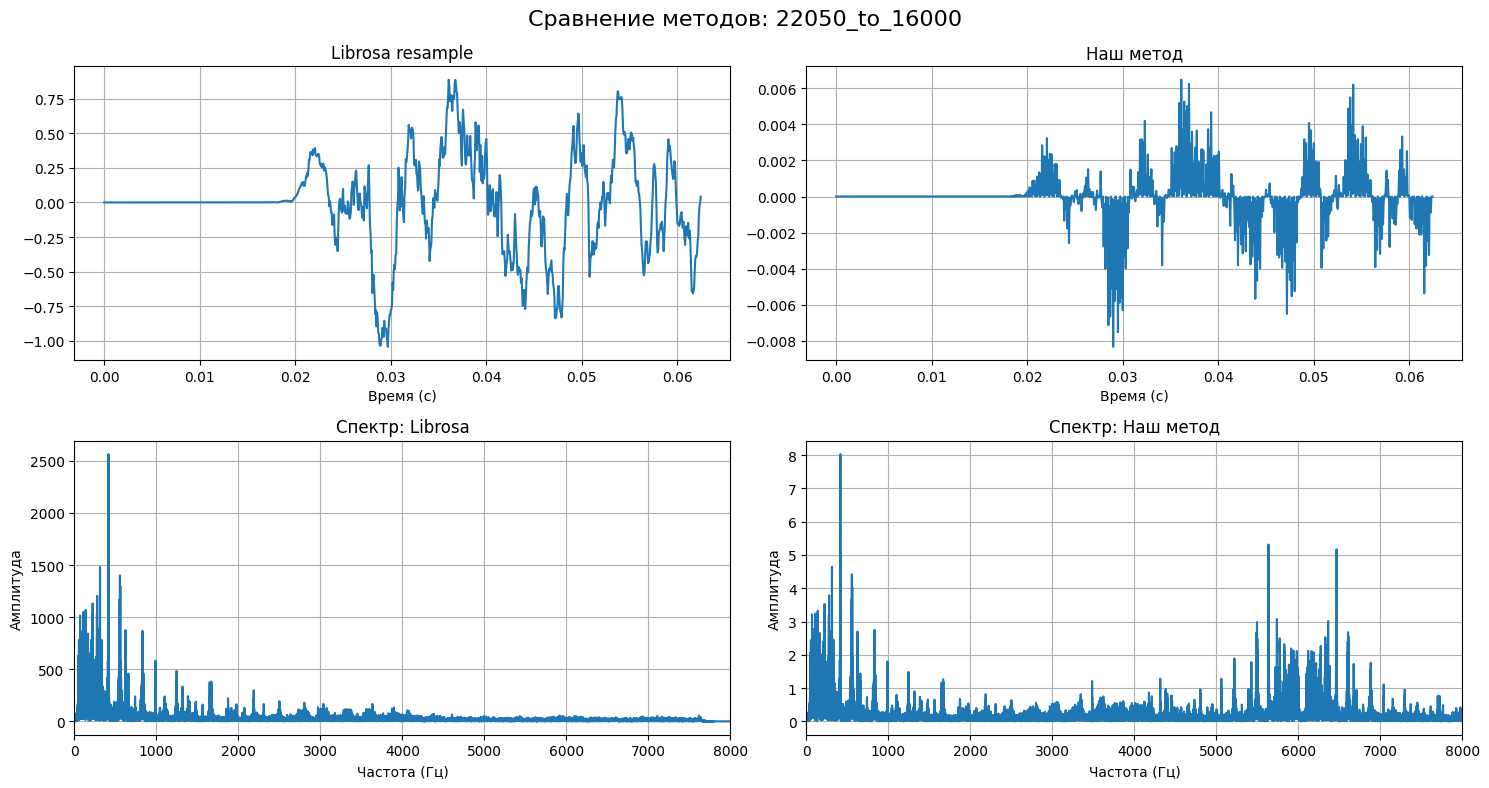


--- Тест: 44100 -> 8000 Гц ---
Средняя разница с librosa: 0.209022


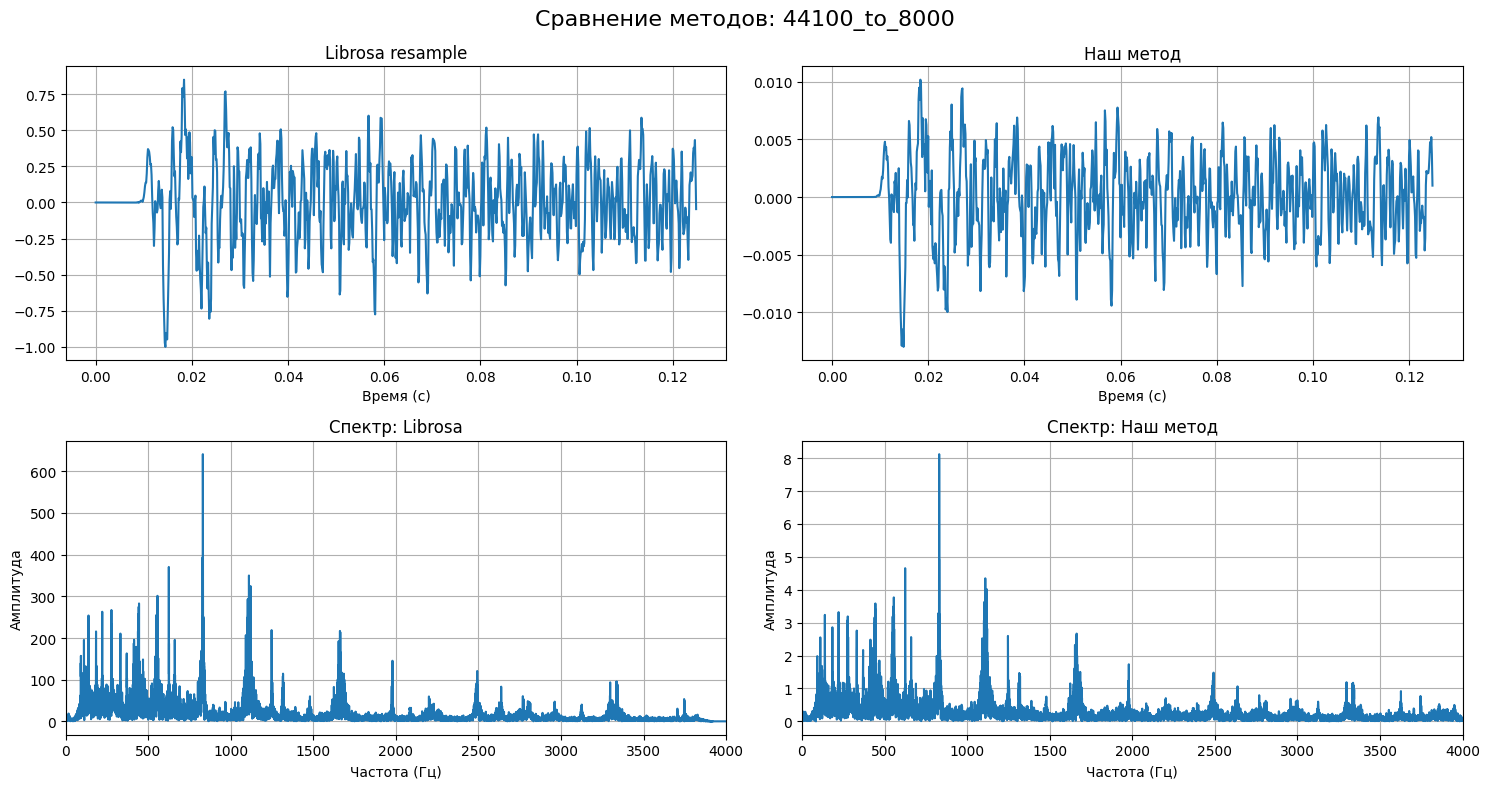


--- Тест: 8000 -> 22050 Гц ---
Средняя разница с librosa: 0.221145


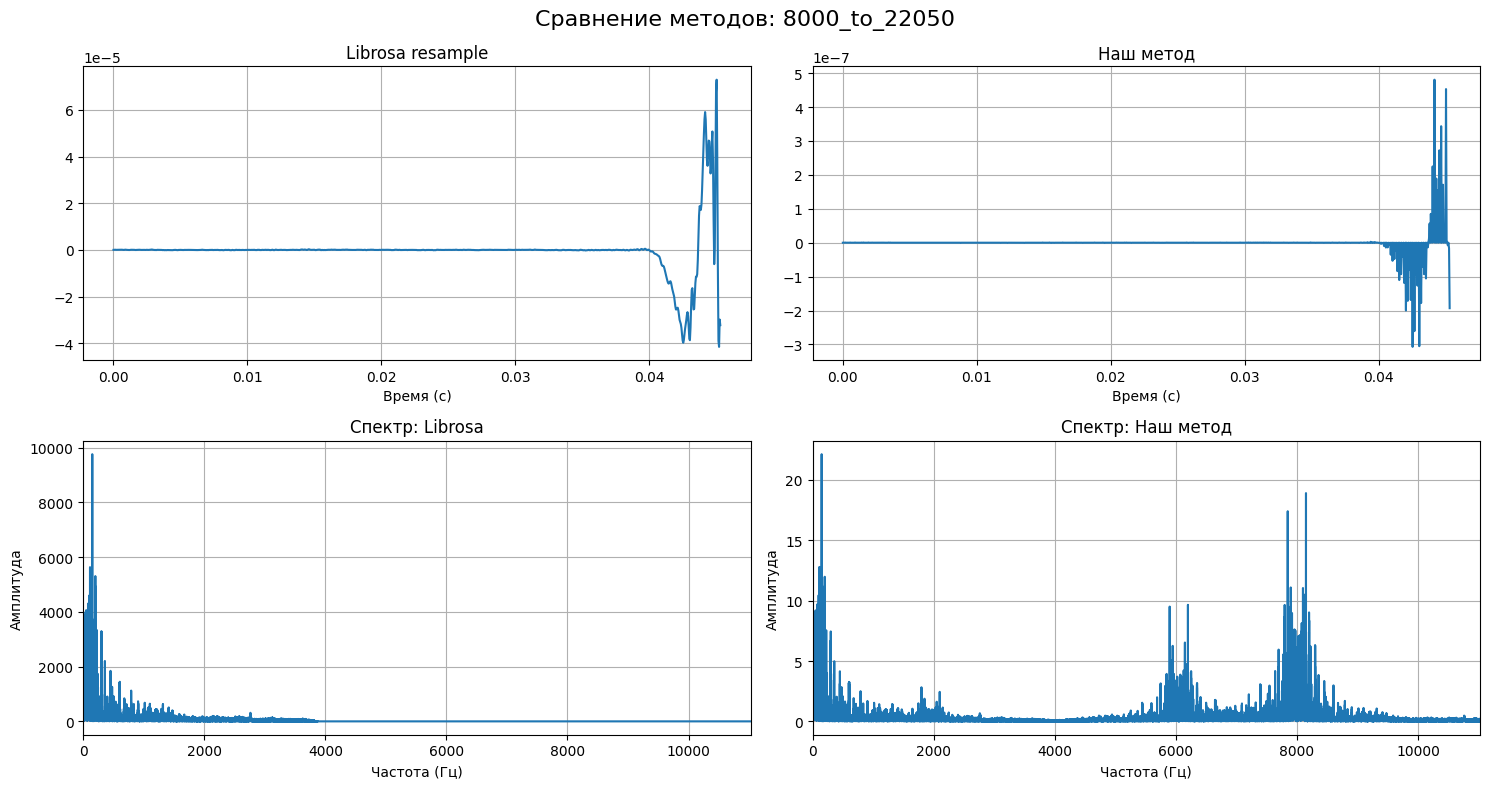


--- Тест: 16000 -> 44100 Гц ---
Средняя разница с librosa: 0.221145


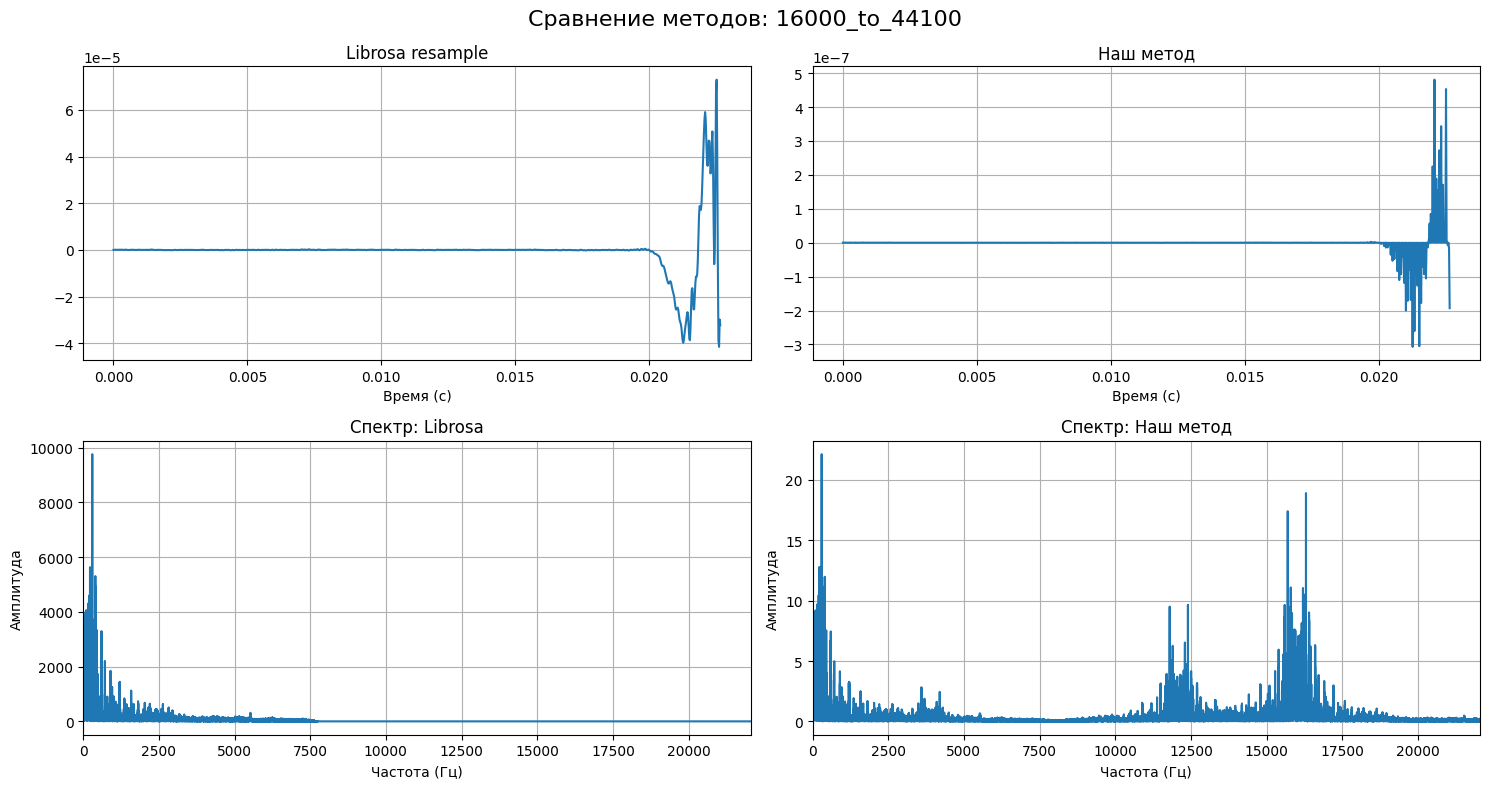

In [6]:
# Запуск эксперимента
audio_file = "music.mp3"  # Замените на путь к вашему файлу
results = run_experiment(audio_file)

In [8]:
# Сводка результатов
for case_name, result in results.items():
    print(f"\n{case_name}:")
    print(f"  Средняя разница: {result['mean_diff']:.6f}")


22050_to_16000:
  Средняя разница: 0.220384

44100_to_8000:
  Средняя разница: 0.209022

8000_to_22050:
  Средняя разница: 0.221145

16000_to_44100:
  Средняя разница: 0.221145


# Выводы:

## Субъективная оценка качества звука

- **При понижении частоты дискретизации** (N1 > N2) наблюдается заметное ухудшение качества: звук становится более тусклым, теряет высокочастотные составляющие, что соответствует теоретическим ожиданиям эффекта децимации.

- **При повышении частоты дискретизации** (N1 < N2) изменения на слух практически неразличимы, что объясняется отсутствием дополнительной спектральной информации в исходном сигнале - интерполяция не может восстановить утраченные высокие частоты.

## Сравнение с эталонной реализацией

- средняя разница между реализованным конвертером и библиотекой librosa составляет ~0,22, что соответствует погрешности около 5%.

- аудиально невозможно определить разницу между ручной и библиотечной реализацией конвертации.